In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('../data/raw/earnings_raw.csv')
print(df.shape)

(3213, 9)


In [6]:
df.head

<bound method NDFrame.head of      symbol        date  epsActual  epsEstimated  revenueActual  \
0      AAPL  2026-07-30        NaN          1.86            NaN   
1      AAPL  2026-04-30       2.01          1.95   1.111840e+11   
2      AAPL  2026-01-29       2.85          2.67   1.437560e+11   
3      AAPL  2025-10-30       1.85          1.73   1.024660e+11   
4      AAPL  2025-07-31       1.57          1.44   9.403600e+10   
...     ...         ...        ...           ...            ...   
3208     GE  1986-09-30       0.48           NaN   9.278000e+09   
3209     GE  1986-06-30       0.48           NaN   7.790000e+09   
3210     GE  1986-03-31       0.40           NaN   5.880000e+09   
3211     GE  1985-12-31       0.07           NaN   8.725000e+09   
3212     GE  1985-09-30       0.40           NaN   6.520000e+09   

      revenueEstimated lastUpdated       sector              industry  
0         1.084140e+11  2026-05-18   Technology  Consumer Electronics  
1         1.094576e+1

In [8]:
df. dtypes

symbol               object
date                 object
epsActual           float64
epsEstimated        float64
revenueActual       float64
revenueEstimated    float64
lastUpdated          object
sector               object
industry             object
dtype: object

In [9]:
print(df.isnull().sum())
print()
print(df.dtypes)

symbol                0
date                  0
epsActual            23
epsEstimated        588
revenueActual        59
revenueEstimated    796
lastUpdated           0
sector                0
industry              0
dtype: int64

symbol               object
date                 object
epsActual           float64
epsEstimated        float64
revenueActual       float64
revenueEstimated    float64
lastUpdated          object
sector               object
industry             object
dtype: object


In [12]:
missing_est = df[df['epsEstimated'].isna()]
print(missing_est['date'].min(), missing_est['date'].max())
print(missing_est.groupby('symbol')['date'].count())

1985-08-31 2019-03-28
symbol
AAPL     54
AMZN      5
BA       29
BAC      15
GE       29
GOOGL    10
GS        7
JNJ      29
JPM      50
KO       29
META      5
MSFT     29
NKE      40
PEP      29
PFE      29
SBUX     24
UNH      29
WFC      45
WMT      62
XOM      39
Name: date, dtype: int64


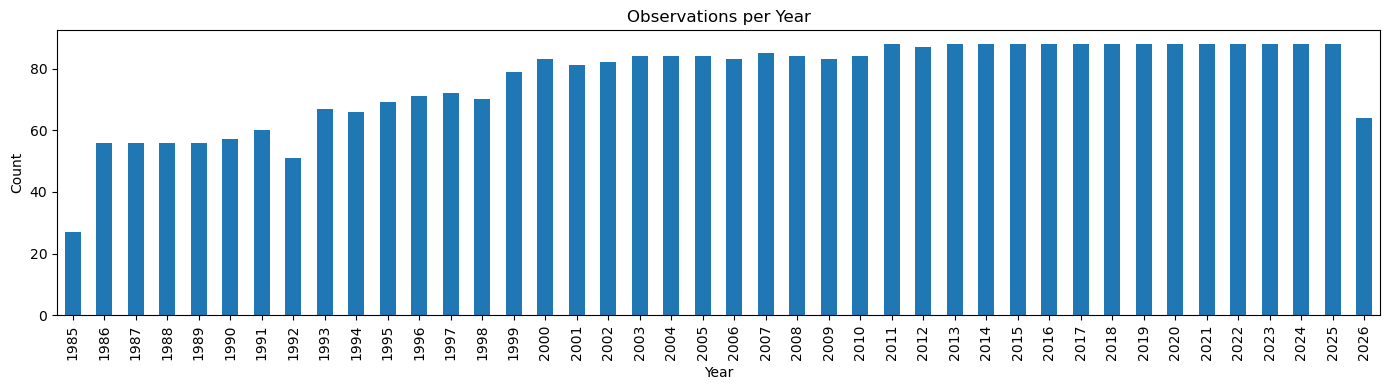

In [13]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

df['year'].value_counts().sort_index().plot(kind='bar', figsize=(14,4), title='Observations per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

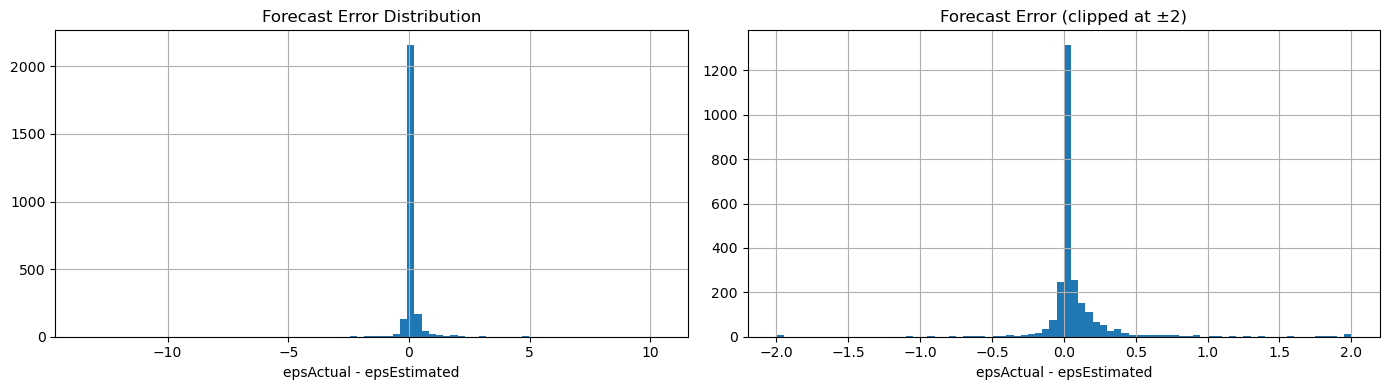

count    2602.000000
mean        0.074530
std         0.552961
min       -13.470000
25%         0.000000
50%         0.020000
75%         0.090000
max        10.358540
Name: forecast_error, dtype: float64


In [14]:
df['forecast_error'] = df['epsActual'] - df['epsEstimated']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['forecast_error'].hist(bins=80, ax=axes[0])
axes[0].set_title('Forecast Error Distribution')
axes[0].set_xlabel('epsActual - epsEstimated')

df['forecast_error'].clip(-2, 2).hist(bins=80, ax=axes[1])
axes[1].set_title('Forecast Error (clipped at ±2)')
axes[1].set_xlabel('epsActual - epsEstimated')

plt.tight_layout()
plt.show()

print(df['forecast_error'].describe())

                         mean  median    std  count
sector                                             
Communication Services  0.154   0.030  0.330    143
Consumer Cyclical       0.039   0.005  0.126    357
Consumer Defensive      0.019   0.010  0.033    368
Energy                  0.041   0.040  0.218    258
Financial Services      0.251   0.050  0.771    456
Healthcare              0.061   0.020  0.133    402
Industrials            -0.032   0.050  1.313    268
Technology              0.028   0.010  0.090    350


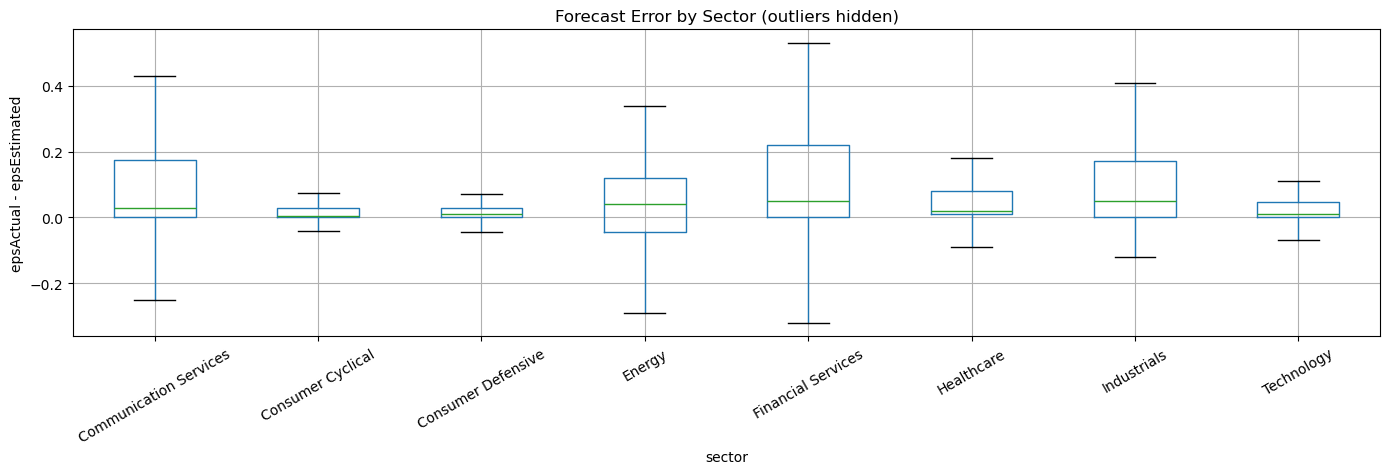

In [15]:
df_clean = df.dropna(subset=['forecast_error'])

sector_bias = df_clean.groupby('sector')['forecast_error'].agg(['mean', 'median', 'std', 'count'])
print(sector_bias.round(3))

df_clean.boxplot(column='forecast_error', by='sector', figsize=(14, 5), 
                 rot=30, showfliers=False)
plt.suptitle('')
plt.title('Forecast Error by Sector (outliers hidden)')
plt.ylabel('epsActual - epsEstimated')
plt.tight_layout()
plt.show()

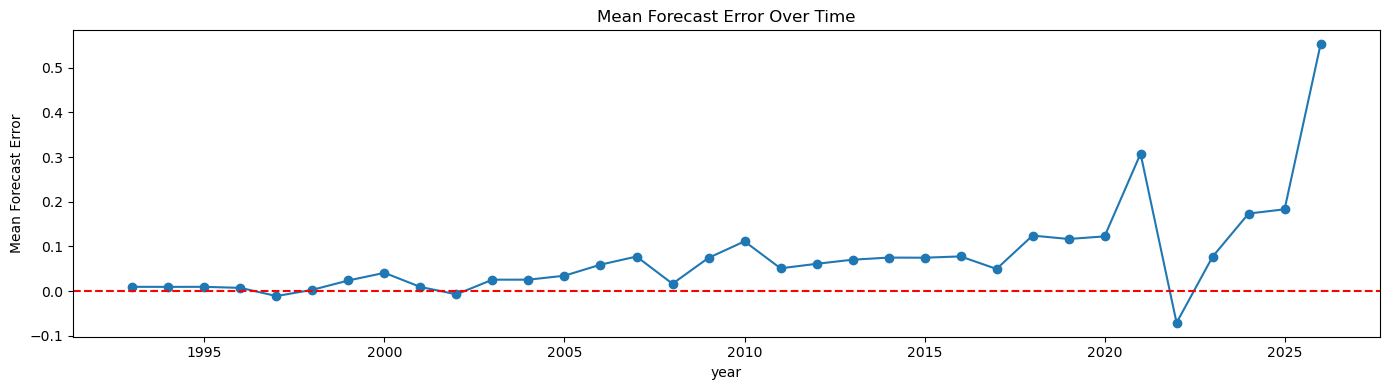

In [16]:
annual = df_clean.groupby('year')['forecast_error'].mean()
annual.plot(figsize=(14, 4), title='Mean Forecast Error Over Time', marker='o')
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('Mean Forecast Error')
plt.tight_layout()
plt.show()